# CDA2: Trend derivation

In this Lesson we will learn some basic techniques of timeseries analysis.  


## Linear Regression with Least Squares Fit


One of the simplest techniques to fit a best fit curve $y$  is the simple linear regression model.

**1. The Linear Model**

We assume our data can be modeled by a linear relationship:

$y = mx + c$


where:

* `y` is the dependent variable.
* `x` is the independent variable.
* `m` is the slope of the line.
* `c` is the y-intercept.

**2. The Least Squares Method**

Our goal is to find the values of $m$ and $c$ that best fit the data. The least squares method minimizes the sum of the squared differences between the observed $y$ values and the predicted $y$ values from our linear model.


Let's say we have $n$ data points: $(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)$. The error (or residual) for each point is:

$e_i = y_i - (m x_i + c)$

<img src="https://upload.wikimedia.org/wikipedia/commons/b/b0/Linear_least_squares_example2.svg" width=300 height=300 />

The sum of squared errors (SSE) is:

$SSE = \sum (y_i - (m x_i + c))^2  $

To minimize SSE, we take the partial derivatives with respect to `m` and `c` and set them to zero:

$\partial (SSE) / \partial c = 0$

and for $m$:

$\partial (SSE) / \partial m = 0$


### Partial Derivative with respect to $c$

To find the minimum, we take the partial derivative with respect to the intercept $c$ and set it to zero:

$$\frac{\partial SSE}{\partial c} = -2 \sum_{i=1}^{n} (y_i - mx_i - c) = 0$$

Divide by $-2$ and distribute the summation:

$$\sum y_i - m \sum x_i - \sum c = 0$$

Since $\sum_{i=1}^{n} c = nc$, we have:

$$nc = \sum y_i - m \sum x_i$$

Dividing by $n$ gives the estimator for the intercept:

$$\hat{c} = \bar{y} - m\bar{x}$$

### Partial Derivative with respect to $m$

Now, we take the partial derivative with respect to the slope $m$ and set it to zero:

$$\frac{\partial SSE}{\partial m} = -2 \sum_{i=1}^{n} x_i (y_i - mx_i - c) = 0$$

Divide by $-2$ and substitute the expression for $c$ ($\bar{y} - m\bar{x}$):

$$\sum x_i (y_i - mx_i - (\bar{y} - m\bar{x})) = 0$$

Rearrange the terms inside the parentheses:

$$\sum x_i ((y_i - \bar{y}) - m(x_i - \bar{x})) = 0$$

Distribute $x_i$:

$$\sum x_i(y_i - \bar{y}) - m \sum x_i(x_i - \bar{x}) = 0$$

### Helpful Identity

The identity $\sum x_i(y_i - \bar{y}) = \sum (x_i - \bar{x})(y_i - \overline{y})$ holds true because subtracting the mean $\overline{x}$ from $x_i$ introduces a term that sums to zero.

To show this, we start by expanding the right-hand side:
$$\sum (x_i - \overline{x})(y_i - \overline{y}) = \sum [x_i(y_i - \overline{y}) - \overline{x}(y_i - \overline{y})]$$

Distribute the summation sign:
$$\sum x_i(y_i - \overline{y}) - \sum \overline{x}(y_i - \overline{y})$$

Since $\overline{x}$ is a constant (it doesn't depend on $i$), we can pull it out of the second summation:
$$\sum x_i(y_i - \overline{y}) - \overline{x} \sum (y_i - \overline{y})$$

Look at the term $\sum (y_i - \overline{y})$. By the definition of the arithmetic mean:
$$\sum (y_i - \overline{y}) = \sum y_i - \sum \overline{y} = \sum y_i - n\overline{y}$$
Since $n\overline{y} = \sum y_i$, this becomes:
$$\sum y_i - \sum y_i = 0$$

...and thus
$$\sum x_i(y_i - \overline{y}) - \overline{x}(0) = \sum x_i(y_i - \overline{y})$$

This trick allows us to transition from raw values to *deviations from the mean*.

### Solving for the Slope ($m$)
Using the mathematical identity where $\sum x_i(y_i - \bar{y}) = \sum (x_i - \bar{x})(y_i - \bar{y})$ and $\sum x_i(x_i - \bar{x}) = \sum (x_i - \bar{x})^2$, we isolate $m$:

$$m \sum (x_i - \bar{x})^2 = \sum (x_i - \bar{x})(y_i - \bar{y})$$

The final estimator for the slope is:

$$\hat{m} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

### Summary of slope and intercept estimators

* Slope:
  \begin{equation}
     \hat{m} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}   \tag{1}
  \end{equation}
  
* Intercept:
  \begin{equation}
   \hat{c} = \bar{y} - \hat{m} \bar{x}    \tag{2}
   \end{equation}

Where $\bar{x}$ and $\bar{y}$ are the sample means of $x$ and $y$, respectively.

Let's code this up from scratch (we will compare this to the scipy package calculation next)



In [51]:
import numpy as np
import matplotlib.pyplot as plt

def linear_regression(x, y):
    """
    Fits a linear model to the data using the least squares method.

    Args:
        x: Array of x values.
        y: Array of y values.

    Returns:
        m: Slope of the line.
        c: Y-intercept of the line.
    """
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x2 = np.sum(x**2)

    
    m = np.sum((x-np.mean(x))*(y-np.mean(y)))/np.sum((x-np.mean(x))**2) # slow way

    # equivalent form which is faster and more concise (add to lecture equations)
    # m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    
    c = (sum_y - m * sum_x) / n
    
    return m, c

In [52]:
def plot_scatter(x,y,y_pred):

    # Plot the data and the regression line
    plt.scatter(x, y, label='Data points')
    plt.plot(x, y_pred, color='red', label=f'Linear fit: y = {m:.2f}x + {c:.2f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Linear Regression')
    plt.show()

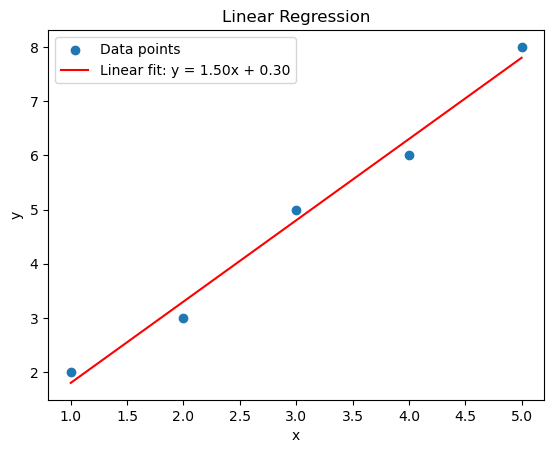

Slope (m): 1.5
Y-intercept (c): 0.3


In [53]:
# Example data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 6, 8])

# Calculate slope and intercept
m, c = linear_regression(x, y)

# Generate predicted y values
y_pred = m * x + c

plot_scatter(x,y,y_pred)

print(f"Slope (m): {m}")
print(f"Y-intercept (c): {c}")

### Scipy package

Let's do a quick cross check that the scipy package gives the same result:

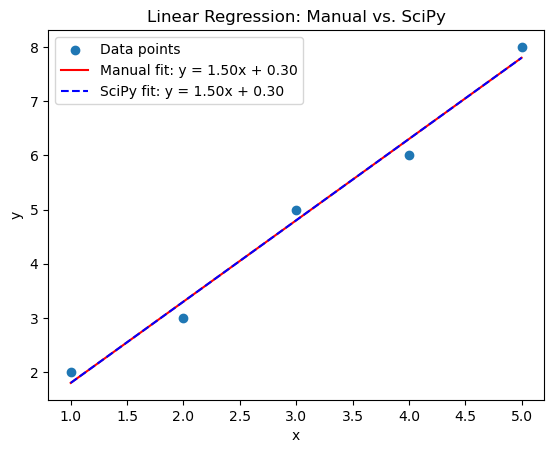

In [54]:
from scipy.stats import linregress
# SciPy calculation
slope_scipy, intercept_scipy, r_value, p_value, std_err = linregress(x, y)
y_pred_scipy = slope_scipy * x + intercept_scipy

# Plotting
plt.scatter(x, y, label='Data points')
plt.plot(x, y_pred, color='red', label=f'Manual fit: y = {m:.2f}x + {c:.2f}')
plt.plot(x, y_pred_scipy, color='blue', linestyle='--', label=f'SciPy fit: y = {slope_scipy:.2f}x + {intercept_scipy:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression: Manual vs. SciPy')
plt.legend()
plt.show()

### EXERCISES: Investigation where we "know" the answer

Let's try that again but rather than a set of datapoints with an unknown relationship, here we will make up a dataset where we *know* the answer by defining an artificial dataset according to $$ y_i = m x_i + c + \epsilon_i $$ where $\epsilon$ is a Gaussian random variable of a magnitude to be defined. 


<div class="alert alert-info">

Investigation:
  * What happens if you set the noise magnitude to ZERO?  you could get a perfect regression line hopefully
  * Increase the magnitude of the noise (e.g. to 5) - how close is the prediction line to the true value?
  * Run it again! Is the regression line the same as it was the previous time?
  * Investigate how the "uncertainty" of the slope and intercept fits changes as a function of 1) Noise magnitude 2) true slope 3) dataset size and 4) the xrange...


</div>



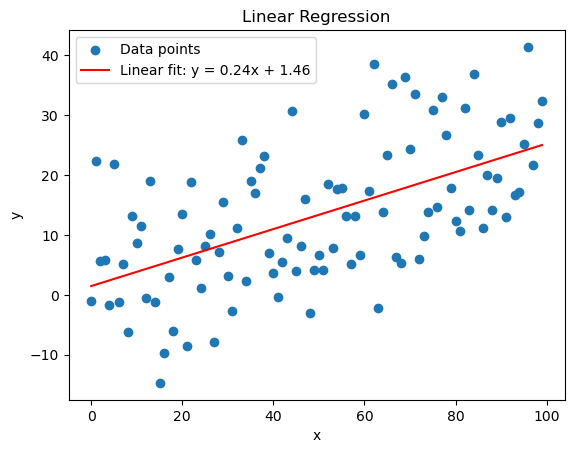

Slope (m): 0.2380824749097804
Y-intercept (c): 1.4598004328912588


In [55]:
### Define the properties of the line

npt=100
noise_mag=10
true_slope=0.2 # m
true_offset=4 # c

x = np.arange(npt)
y = true_slope*x + true_offset + np.random.normal(loc=0, scale=noise_mag, size=npt)

# Calculate slope and intercept
m, c = linear_regression(x, y)

# Generate predicted y values
y_pred = m * x + c

plot_scatter(x,y,y_pred)

print(f"Slope (m): {m}")
print(f"Y-intercept (c): {c}")

we can subtract the fit line to get a plot of the residual

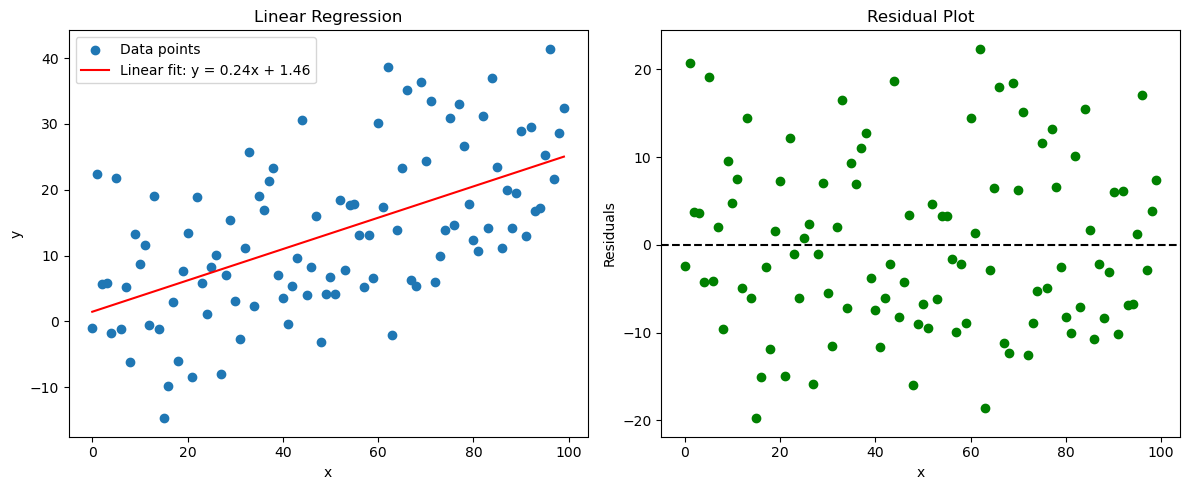

In [56]:

# Plot the data and the regression line using subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) # 1 row, 2 columns

# Subplot 1: Original Data and Regression Line
ax1.scatter(x, y, label='Data points')
ax1.plot(x, y_pred, color='red', label=f'Linear fit: y = {m:.2f}x + {c:.2f}')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Linear Regression')
ax1.legend()

# Subplot 2: Residual Plot
residuals = y - y_pred
ax2.scatter(x, residuals, color='green')
ax2.axhline(y=0, color='black', linestyle='--')
ax2.set_xlabel('x')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot')

plt.tight_layout() # Improves subplot spacing
plt.show()


## Defining the Coefficient of Determination ($r^2$)
By definition, the proportion of the total variation explained by the model is:
$$r^2 = \frac{SS_{reg}}{SS_{tot}}$$

Substituting $SS_{reg} = SS_{tot} - SS_{res}$:
$$r^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

---

## 3. Connecting $R^2$ to Pearson's $r$
To prove that this $R^2$ is exactly the square of the Pearson correlation ($r$), we use the linear model $\hat{y}_i = \hat{m}x_i + \hat{c}$.

Recall the relationship derived earlier:
$$\hat{y}_i - \bar{y} = \hat{m}(x_i - \bar{x})$$

Substitute this into the $SS_{reg}$ formula:
$$SS_{reg} = \sum (\hat{m}(x_i - \bar{x}))^2 = \hat{m}^2 \sum (x_i - \bar{x})^2$$

From our previous derivation, we know $\hat{m} = r \frac{s_y}{s_x}$. Squaring it gives:
$$\hat{m}^2 = r^2 \frac{s_y^2}{s_x^2}$$

Now substitute $\hat{m}^2$ into the $SS_{reg}$ equation:
$$SS_{reg} = \left( r^2 \frac{s_y^2}{s_x^2} \right) \sum (x_i - \bar{x})^2$$

Since $s_x^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$, then $\sum (x_i - \bar{x})^2 = (n-1)s_x^2$:
$$SS_{reg} = r^2 \frac{s_y^2}{s_x^2} \cdot (n-1)s_x^2$$
$$SS_{reg} = r^2 \cdot (n-1)s_y^2$$

Since $(n-1)s_y^2$ is exactly $SS_{tot}$, we get:
$$SS_{reg} = r^2 \cdot SS_{tot}$$

Dividing both sides by $SS_{tot}$:
$$\frac{SS_{reg}}{SS_{tot}} = r^2$$

---

## 4. Final Conclusion
The square of the Pearson correlation coefficient ($r^2$) is identically equal to the proportion of variance in $Y$ that is explained by the linear relationship with $X$.

| Component | Proportion of Variance |
| :--- | :--- |
| **Explained ($SS_{reg}$)** | $r^2$ |
| **Unexplained ($SS_{res}$)** | $1 - r^2$ |

## Derivation of Standard Errors for Intercept and Slope in Linear Regression

In the above we simply assumes a linear model without recourse to uncertainty in the data. In order to consider this we need to make further assumptions about the data, we now generalize the equation to account for uncertainty.  

In the following $x$ refers to our explaining variable, often referred to as the **independent variable**.  We assume that our **dependent variable** $y$ is related to $x$ linearly, but now subject to an error, or **uncertainty**, which we represent by $\epsilon$. 

### Causes of uncertainty

This uncertainty could have many sources. It could include all the following:

* **measurement uncertainty** in the independent and/or dependent variable; instrument accuracy for example. 

* **multiple explaining variables**: the dependent variable could have multiple explaining variables, some of which are *unknown* or *unobserved/unobservable*.  For example, ice cream sales are likely to be a function of temperature, but also of population density and also the state of the economy, which also change in time and location.  Thus relating the former only to temperature will neglect the latter two which will introduce **spread** in the ice cream-temperature relationship.

* **Nonlinearity** Lastly of course, recall that we are assuming the relational is linear, whereas in reality the relationship is often nonlinear and more complicated. 




### Results of the uncertainty

This uncertainty means that the slope (and intercept) estimated from a sample will be subject to uncertainty, due to the limited and imperfect sample we have. If we took a different sample of the same size, we’d likely get a slightly different $m$ due to the uncertainty.  Thus we need to estimate the variance of the slope, to tell us how much that $m$ is expected to change across different samples.

In other words, if we collected a new set of data $y_i$ for the same $x_i$ values, we would get a slightly different $\hat{m}$. To understand how reliable our estimate is, we must ask:

> **Is our estimate precise?** A low variance means our calculated slope is likely very close to the "true" population slope $m$.

> **How can we perform hypothesis testing?** To test if $x$ actually affects $y$ (i.e., testing if $m \neq 0$), we need to know the standard deviation of our estimate.

> **How do we build confidence intervals?** We need the variance to say, "We are 95% confident the true slope is between $m_1$ and $m_2$."

Therefore, we must derive the **Variance of the Slope**, denoted as $Var(\hat{m})$, by propagating the variance of the error terms ($\sigma^2$) through our slope formula.


Thus we write 

$$y_i = c + m x_i + \epsilon_i$$

Where:

* $y_i$ is the dependent variable for the $i$-th observation.
* $x_i$ is the independent variable for the $i$-th observation.
* $c$ is the "true" intercept.
* $m$ is the "true" slope.
* $\epsilon_i$ is the error term for the $i$-th observation.


We make the following assumptions about the error terms:

* $E(\epsilon_i) = 0$ (mean of zero).
* $Var(\epsilon_i) = \sigma^2$ (constant variance).
* $\epsilon_i$ are independent.
* In general, we need to assume $\epsilon_i$ are normally distributed.

We defined the variance for the error term $\epsilon_i$, but it turns out that we can also assume this variance for the dependent variable $y_i$, i.e. in reality, they are the same.

Recall our model equation:
$$y_i = mx_i + c + \epsilon_i$$

In this model, we treat $x_i$, $m$, and $c$ as **fixed constants** for a specific observation. The only "random" part of $y_i$ comes from the error term $\epsilon_i$. 

Using the properties of variance:
1. $Var(y_i) = Var(mx_i + c + \epsilon_i)$
2. Since $mx_i + c$ is a constant, its variance is $0$.
3. Therefore: $Var(y_i) = Var(\epsilon_i) = \sigma^2$

### Derivation of $Var(\hat{m})$

To find the variance of the slope, we treat the $x_i$ values as fixed constants and the $y_i$ values as random variables.

#### Simplify the Slope Formula
Recall the estimator for $m$:
$$\hat{m} = \frac{\sum (x_i - \overline{x})(y_i - \overline{y})}{\sum (x_i - \overline{x})^2}$$

To make the math easier, let $w_i = \frac{(x_i - \overline{x})}{\sum (x_i - \overline{x})^2}$. These are our "weights." 
Now we can write the slope as a linear combination of $y_i$:
$$\hat{m} = \sum w_i (y_i - \bar{y}) = \sum w_i y_i$$
where we used the identity again to drop $\bar{y}$

#### Apply the Variance Property
Since the $y_i$ are independent, the variance of the sum is the sum of the variances. Also, recall that $Var(a \cdot Y) = a^2 \cdot Var(Y)$:
$$Var(\hat{m}) = Var\left( \sum w_i y_i \right) = \sum w_i^2 Var(y_i)$$

#### Substitute the Error Variance ($\sigma^2$)
In the standard regression model, recall that we assume $Var(y_i) = \sigma^2$ for all $i$ (homoscedasticity):
\begin{equation}
  Var(\hat{m}) = \sum w_i^2 \sigma^2 = \sigma^2 \sum w_i^2  \tag{3}
\end{equation}

#### Expand the Weights ($w_i$)
Now we substitute $w_i$ back into the equation:
$$\sum w_i^2 = \sum \left[ \frac{(x_i - \overline{x})}{\sum (x_j - \overline{x})^2} \right]^2 = \frac{\sum (x_i - \overline{x})^2}{\left[ \sum (x_i - \overline{x})^2 \right]^2}$$

One of the terms in the numerator cancels out one in the denominator:
$$\sum w_i^2 = \frac{1}{\sum (x_i - \overline{x})^2}$$

#### The Final Variance Formula
Substituting this back into eqn. 3 we get the theoretical variance:

\begin{equation}
  Var(\hat{m}) = \frac{\sigma^2}{\sum (x_i - \overline{x})^2} \tag{4}
\end{equation}


### Estimating the Variance from Data
Since we don't know the true population variance $\sigma^2$, we use the **Mean Squared Error (MSE)** as an unbiased estimator:

$$\hat{s}^2 = MSE = \frac{\sum (y_i - \hat{y}_i)^2}{n - 2}$$
*Note: We divide by $n-2$ because we estimated two parameters ($m$ and $c$), losing two degrees of freedom.*

#### Standard Error ($SE$) of $\hat{m}$
The Standard Error is simply the square root of our estimated variance:
\begin{equation}
SE(\hat{m}) = \sqrt{\frac{MSE}{\sum (x_i - \overline{x})^2}} = \sqrt{\frac{\sum(y_i - \hat{y}_i)^2}{(n-2)\sum (x_i - \overline{x})^2}} \tag{5}
\end{equation}


In [5]:
# let's calculate that
def calculate_se_slope(x, y, m, c):
    """
    Calculates the Standard Error of the slope (m).
    """
    n = len(x)
    # 1. Calculate Predicted Y and Residuals
    y_pred = m * x + c
    residuals = y - y_pred
    
    # 2. Calculate Mean Squared Error (MSE) - using n-2 degrees of freedom
    mse = np.sum(residuals**2) / (n - 2)
    
    # 3. Calculate Sum of Squares for x (Denominator)
    ssx = np.sum((x - np.mean(x))**2)
    
    # 4. Standard Error of m
    se_m = np.sqrt(mse / ssx)
    
    return se_m

### Variance of the Intercept ($c$)


To find the variance of the intercept, we start with the estimator we derived earlier:
$$\hat{c} = \overline{y} - \hat{m}\overline{x}$$

#### Express as a Variance of a Sum
Using the property $Var(A - B) = Var(A) + Var(B) - 2Cov(A, B)$, we write:
$$Var(\hat{c}) = Var(\overline{y} - \hat{m}\overline{x}) = Var(\overline{y}) + \overline{x}^2 Var(\hat{m}) - 2\overline{x} Cov(\overline{y}, \hat{m})$$

### Calculate the Individual Components
Let's look at these 3 terms in turn. 

Firstly 

### a) Variance of the mean:** $Var(\overline{y}) = \frac{\sigma^2}{n}$

To get this, we start with the definition of the sample mean:
$$\overline{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$$

#### Apply the Variance Operator
Take the variance of both sides:
$$Var(\overline{y}) = Var\left( \frac{1}{n} \sum_{i=1}^{n} y_i \right)$$

#### Pull out the Constant
Recall the variance property: $Var(aX) = a^2 Var(X)$. Here, our constant $a$ is $\frac{1}{n}$:
$$Var(\overline{y}) = \left( \frac{1}{n} \right)^2 Var\left( \sum_{i=1}^{n} y_i \right)$$

#### Sum of Variances
Because our observations $y_i$ are assumed to be **independent**, the variance of a sum is equal to the sum of the individual variances:
$$Var(\overline{y}) = \frac{1}{n^2} \sum_{i=1}^{n} Var(y_i)$$

####  Substitute the Constant Variance ($\sigma^2$)
Under our regression assumptions (**Homoscedasticity**), every observation $y_i$ has the same variance, $\sigma^2$:
$$Var(\overline{y}) = \frac{1}{n^2} \sum_{i=1}^{n} \sigma^2$$

Since we are adding $\sigma^2$ to itself $n$ times:
$$\sum_{i=1}^{n} \sigma^2 = n\sigma^2$$

Substitute this back into the equation:
$$Var(\overline{y}) = \frac{1}{n^2} (n\sigma^2) = \frac{n\sigma^2}{n^2}$$

this gives
$$Var(\overline{y}) = \frac{\sigma^2}{n}$$


### Intuitive Takeaway:
* If $n=1$, the variance of the mean is just the variance of that single point ($\sigma^2$).
* As $n \to \infty$, the variance of the mean approaches $0$. 
* This shows that **larger samples provide a much more reliable estimate of the average** than small samples.

### b) Variance of the slope:

** This is from equation 4 above: $Var(\hat{m}) = \frac{\sigma^2}{\sum (x_i - \overline{x})^2}$

### c) Handle the Covariance Term
It can be shown that in simple linear regression, the covariance between the sample mean $\overline{y}$ and the slope $\hat{m}$ is zero 

$$Cov(\overline{y}, \hat{m}) = 0$$

This is because $\hat{m}$ depends on the deviations $(y_i - \overline{y})$, which are independent of the mean $\overline{y}$ itself.


#### Substitute back into the Equation
Now we substitute these
$$Var(\hat{c}) = \frac{\sigma^2}{n} + \overline{x}^2 \left( \frac{\sigma^2}{\sum (x_i - \overline{x})^2} \right)$$

#### Factor out $\sigma^2$
To get the final standard form, we factor out the common error variance:
$$Var(\hat{c}) = \sigma^2 \left( \frac{1}{n} + \frac{\overline{x}^2}{\sum (x_i - \overline{x})^2} \right)$$

### Estimating the Standard Error
Since $\sigma^2$ is unknown, we substitute it with the **Mean Squared Error (MSE)**,  denoted as $s^2$ (*as already given above*), but to remind ourselves:

$$s^2 = MSE = \frac{\sum (y_i - \hat{y}_i)^2}{n - 2}$$

#### Standard Error ($SE$) of $\hat{c}$
Taking the square root gives us the standard error used for hypothesis testing on the intercept:
\begin{equation}
SE(\hat{c}) = \sqrt{s^2 \left( \frac{1}{n} + \frac{\overline{x}^2}{\sum (x_i - \overline{x})^2} \right)} \tag{6}
\end{equation}


In [6]:
# let's code it up!

def calculate_se_intercept(x, y, m, c):
    """
    Calculates the Standard Error of the intercept (c).
    """
    n = len(x)
    x_mean = np.mean(x)
    
    # 1. Calculate Predicted Y and Residuals
    y_pred = m * x + c
    residuals = y - y_pred
    
    # 2. Calculate Mean Squared Error (MSE)
    mse = np.sum(residuals**2) / (n - 2)
    
    # 3. Calculate Sum of Squares for x
    ssx = np.sum((x - x_mean)**2)
    
    # 4. Standard Error of c
    se_c = np.sqrt(mse * (1/n + (x_mean**2 / ssx)))
    
    return se_c

### Summary

* The standard errors quantify the uncertainty in the estimated intercept and slope.
* The derivations rely on the properties of variance and expected values.
* The standard errors are influenced by:
    * The residual variance ($s^2$).
    * The sample size ($n$).
    * The spread of the $x$ values.
* The $(n-2)$ term in the MSE accounts for the degrees of freedom lost during estimate.

### Constructing the Confidence Interval (CI)

We use the **t-statistic** corresponding to our desired confidence level ($\alpha$) and our degrees of freedom ($df = n - 2$).

For any confidence level (e.g., 95%, where $\alpha = 0.05$), the interval for the slope $m$ is:

$$\text{CI(m)} = \hat{m} \pm \left( t_{\alpha/2, n-2} \times SE(\hat{m}) \right)$$

* **$\hat{m}$**: Our calculated sample slope.
* **$t_{\alpha/2, n-2}$**: The critical value from the t-distribution table.
* **$SE(\hat{m})$**: The standard error we derived.

Thus if this CI doesn't include zero, it is the equivalent of saying 
$$
|\hat{m}|> t_{\alpha/2, n-2} \times SE(\hat{m})
$$

thus 
$$
\frac{|\hat{m}|}{SE(\hat{m})} > t_{\alpha/2, n-2}
$$

* **Small Samples:** For small $n$, the t-distribution has "fatter tails" than the normal distribution, meaning our uncertainty is higher, and the multiplier will be **larger** than $1.96$.

* **Large Samples ($n \to \infty$):** As the sample size grows, the t-distribution converges to the standard normal distribution. For a 95% confidence level, the value $t_{0.025, n-2}$ approaches **1.96**.  In practice, any sample of roughly $n\ge 30$ is large enough to use a normal distribution z statistic.  

$$\text{95\% CI(m)} = \hat{m} \pm (1.96 \times SE(\hat{m}))$$

*If this interval **does not** include zero, we can confidently say that $x$ has a statistically significant effect on $y$.*

In [7]:
from scipy import stats

def tstatistic(n,alpha=0.05):
    # For 95% confidence and n=20 (df=18)
    df = n - 2
    t_crit = stats.t.ppf(1 - alpha/2, df)
    return (t_crit)

def check_significance(val, se, n, alpha=0.05):
    """Calculates t-statistic and returns if significant (True/False)"""
    df = n - 2
    t_stat = np.abs(val / se)
    t_crit = stats.t.ppf(1 - alpha/2, df)
    is_significant = t_stat > t_crit
    return t_stat, t_crit, is_significant
    
print(tstatistic(30))


2.048407141795245


# Application to CRU temperature data

We will know apply these methods to temperature data from CRU to calculate mean temperature trends.  First let's get a file


Variables found in file: ['time', 'time_bnds', 'lon', 'lat', 'tmx', 'stn']
Using variable: 'tmx'
Processing global trends...


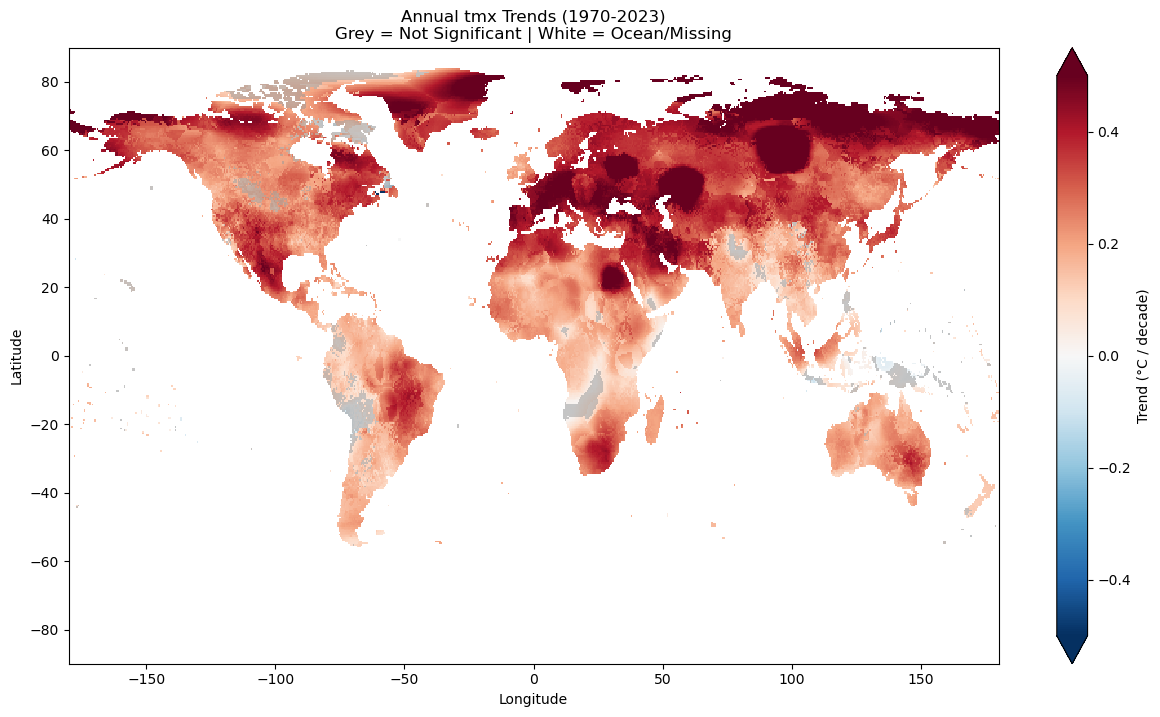

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from netCDF4 import Dataset, num2date
from scipy import stats

# --- 1. Custom Statistical Routines ---

def linear_regression(x, y):
    n = len(x)
    x = np.asarray(x, dtype=float)
    # y is the 3D data array (time, lat, lon)
    x_adj = x[:, np.newaxis, np.newaxis]
    sum_x = np.sum(x)
    sum_y = np.sum(y, axis=0)
    sum_xy = np.sum(x_adj * y, axis=0)
    sum_x2 = np.sum(x**2)
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    c = (sum_y - m * sum_x) / n
    return m, c

def calculate_se(x, y, m, c):
    n = len(x)
    x = np.asarray(x, dtype=float)
    x_mean = np.mean(x)
    ssx = np.sum((x - x_mean)**2)
    x_adj = x[:, np.newaxis, np.newaxis]
    y_pred = m * x_adj + c
    # MSE using masked array sum to ignore oceans
    mse = np.ma.sum((y - y_pred)**2, axis=0) / (n - 2)
    return np.sqrt(mse / ssx)

# --- 2. Data Loading & Fixes ---

url = "http://clima-dods.ictp.it/Users/tompkins/data/cru/cru_tmax_yearmean_1970.nc"
print(f"Downloading from {url}...")
r = requests.get(url)
r.raise_for_status()

with Dataset("buffer.nc", mode='r', memory=r.content) as nc:
    print("Variables found in file:", list(nc.variables.keys()))
    
    # Identify the main data variable.
    potential_names = ['tmax', 'tmp', 'tmx', 'temp']
    vname = next((name for name in potential_names if name in nc.variables), None)
    
    if vname is None:
        # Fallback: take the last variable in the list which is usually the data
        vname = list(nc.variables.keys())[-1]
    
    print(f"Using variable: '{vname}'")
    
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    tmax_raw = nc.variables[vname][:] 
    
    # Fix 1: Handle Years accurately
    time_var = nc.variables['time']
    dates = num2date(time_var[:], units=time_var.units)
    years = np.array([d.year for d in dates]).astype(float)

# Fix 2: Longitude Alignment (The "Europe/America Fix")
# We check if lons go from 0-360. If so, we shift them to -180/180.
if np.max(lons) > 180:
    print("Re-aligning longitudes for global view...")
    # Find the index where lons cross 180
    shift_idx = np.argmin(np.abs(lons - 180))
    lons = np.where(lons > 180, lons - 360, lons)
    
    # Sort lons and roll data accordingly
    sort_idx = np.argsort(lons)
    lons = lons[sort_idx]
    tmax_raw = np.take(tmax_raw, sort_idx, axis=2)

# Analysis

print("Processing global trends...")
m_map, c_map = linear_regression(years, tmax_raw)
se_m_map = calculate_se(years, tmax_raw, m_map, c_map)

# Significance assessment
t_stats = np.abs(m_map / se_m_map)
t_crit = stats.t.ppf(1 - 0.05/2, len(years) - 2)
sig_mask = t_stats > t_crit

# Plotting

plt.figure(figsize=(15, 8))
trend_decade = m_map * 10

# Plot the trends
mesh = plt.pcolormesh(lons, lats, trend_decade, 
                      cmap='RdBu_r', vmin=-0.5, vmax=0.5, shading='auto')

# Apply the Grey Mask for non-significant land
# We check the .mask property of the netcdf data to identify ocean
is_land = ~m_map.mask if hasattr(m_map, 'mask') else ~np.isnan(m_map)
grey_overlay = np.where(~sig_mask & is_land, 1, np.nan)

plt.pcolormesh(lons, lats, grey_overlay, 
               cmap='Greys', vmin=0, vmax=2, alpha=0.5, shading='auto')

plt.colorbar(mesh, label='Trend (°C / decade)', extend='both')
plt.title(f"Annual {vname} Trends ({int(years[0])}-{int(years[-1])})\n"
          "Grey = Not Significant | White = Ocean/Missing")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


<summary>
    We could have achieved the same using the following cdo command:
    <details>
        cdo trend in.nc out.nc
    </details>
</summary>
